# Sentiment Analysis for Mental Health

## 1.Importing Libraries

In [1]:
# for data handling
import numpy as np
import pandas as pd

# for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# text processing libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Models
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding, LSTM, Dense, Dropout,Bidirectional
from tensorflow.keras.preprocessing import sequence
from keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


from collections import Counter
# Tokenize and pad sequences
from tensorflow.keras.preprocessing.text import Tokenizer

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


## 2. Exploratory Data Analysis


In [2]:
# importing data
df=pd.read_csv('/content/Combined Data.csv')
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


* Checking for null values

In [4]:
df[df.statement.isna()==True].shape

(362, 3)

In [5]:
df.dropna(inplace=True)

In [6]:
df.statement.isna().unique()

array([False])

In [7]:
df.status.unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [8]:
for i in df.status.unique():
  print(i,df[df.status==i].shape[0])

Anxiety 3841
Normal 16343
Depression 15404
Suicidal 10652
Stress 2587
Bipolar 2777
Personality disorder 1077


## Plotting 12 most common words in each category of status

In [9]:
# first removing stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
STOPWORDS=set(stopwords.words('english'))
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Most Common words for Anxiety: [('anxiety', 3725), ('like', 3276), ('feel', 2284), ('get', 1984), ('know', 1852), ('time', 1630), ('really', 1603), ('something', 1274), ('back', 1267), ('even', 1223), ('going', 1187), ('go', 1184)]


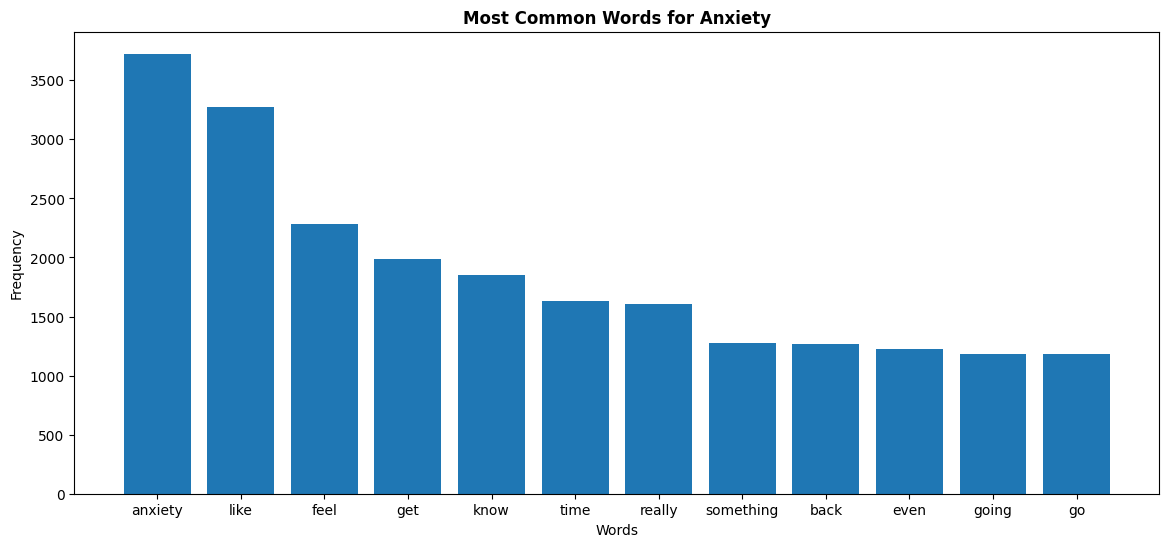

Most Common words for Normal: [('like', 1235), ('want', 1120), ('get', 874), ('really', 860), ('time', 809), ('one', 757), ('go', 755), ('know', 736), ('good', 677), ('would', 651), ('people', 643), ('day', 616)]


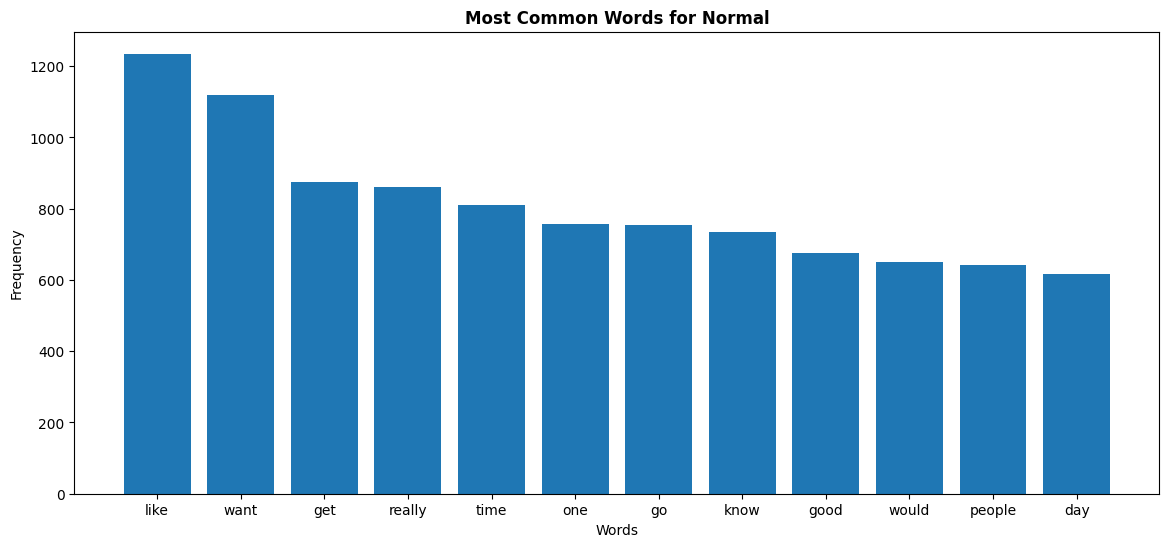

Most Common words for Depression: [('like', 18277), ('feel', 16539), ('want', 12124), ('life', 11130), ('know', 10833), ('get', 9992), ('even', 9171), ('time', 8318), ('people', 7903), ('would', 7418), ('really', 7200), ('one', 6398)]


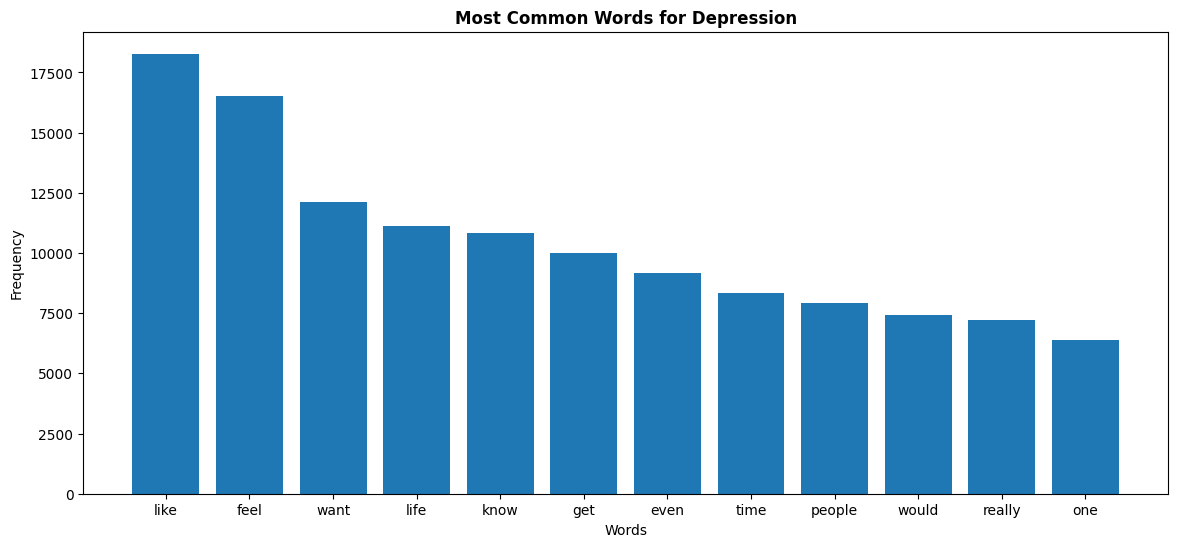

Most Common words for Suicidal: [('want', 10640), ('like', 9116), ('life', 7700), ('feel', 7520), ('know', 6545), ('would', 5729), ('get', 5223), ('even', 5180), ('people', 4754), ('anymore', 4416), ('going', 4269), ('time', 4179)]


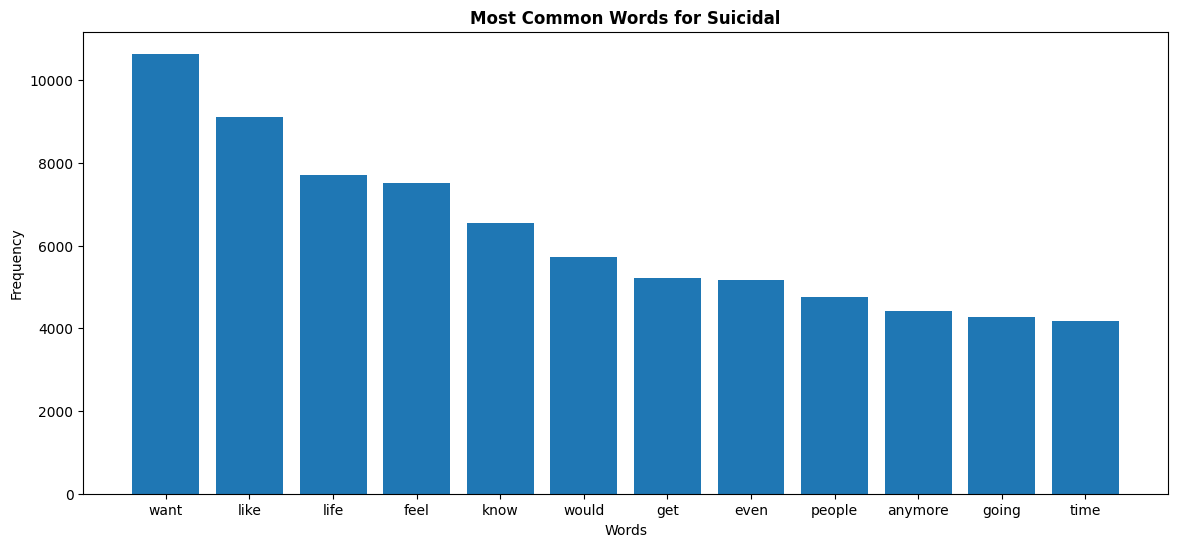

Most Common words for Stress: [('like', 1725), ('stress', 1490), ('feel', 1338), ('get', 1207), ('know', 1023), ('time', 1011), ('even', 805), ('work', 790), ('really', 773), ('help', 706), ('life', 654), ('anxiety', 646)]


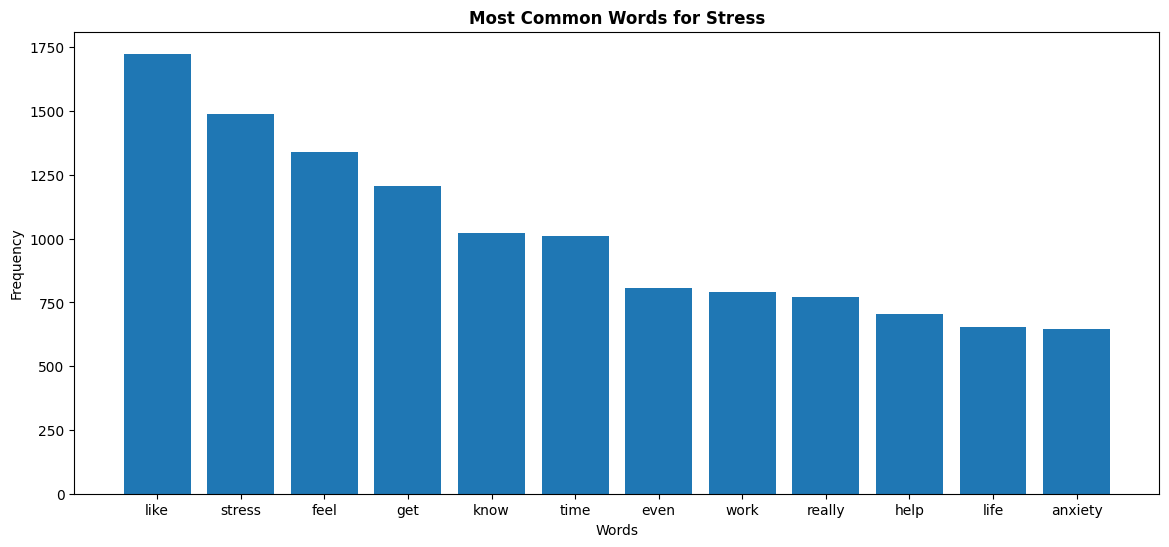

Most Common words for Bipolar: [('like', 3028), ('feel', 2388), ('bipolar', 1837), ('get', 1814), ('know', 1787), ('time', 1496), ('really', 1494), ('want', 1306), ('even', 1107), ('life', 1098), ('one', 1075), ('would', 1074)]


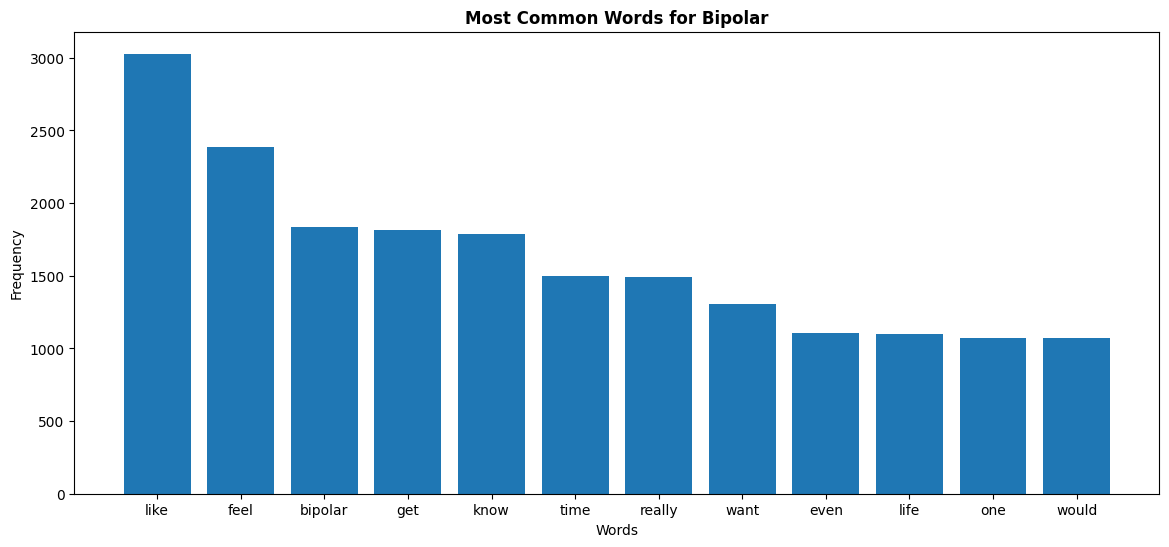

Most Common words for Personality disorder: [('like', 1680), ('people', 1248), ('feel', 1101), ('even', 795), ('know', 788), ('get', 637), ('want', 626), ('avpd', 602), ('life', 600), ('really', 596), ('think', 578), ('one', 538)]


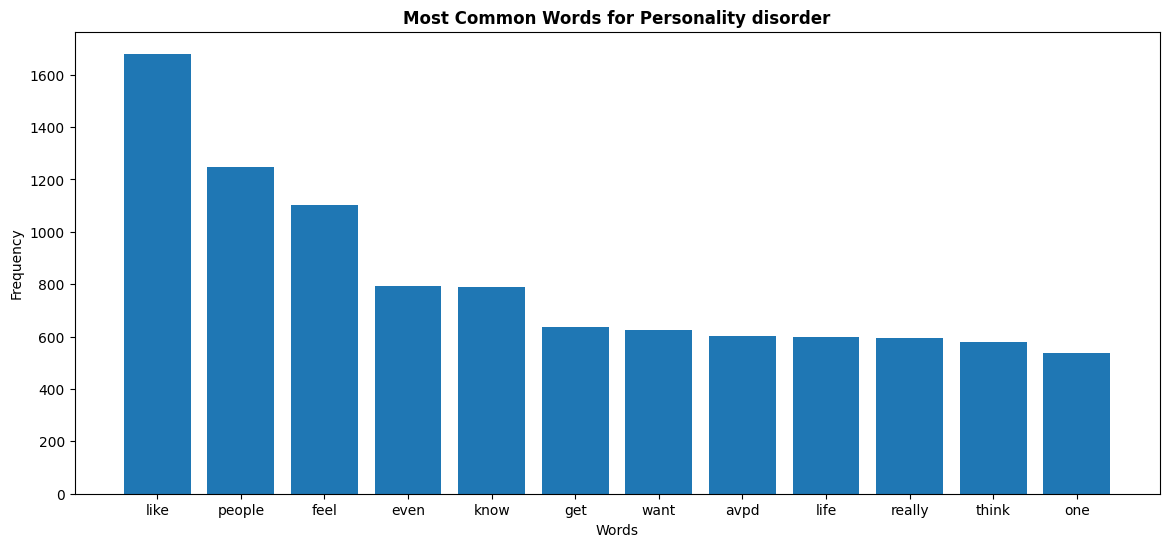

In [10]:
def get_word_freq(status):
  text=' '.join(df[df.status==status]['statement'])
  words=word_tokenize(text.lower())
  words_filtered=[word for word in words if word.isalpha() and word not in STOPWORDS]
  word_freq=Counter(words_filtered)
  return word_freq

statuses=df.status.unique()

for status in statuses:
  word_freq=get_word_freq(status)
  most_common_words=word_freq.most_common(12)
  print(f'Most Common words for {status}: {most_common_words}')

  word,count=zip(*most_common_words)
  plt.figure(figsize=(14,6))
  plt.bar(word,count)
  plt.xlabel('Words')
  plt.ylabel('Frequency')
  plt.title(f'Most Common Words for {status}',fontweight='bold')
  plt.show()

## Analysis of Most Common Words Across Different Mental Health Conditions

The following is an analysis of the most common words used in statements categorized by various mental health conditions. These insights provide a glimpse into the emotional state and focus of individuals experiencing different conditions.

### 1. **Anxiety**
   - **Top Words**: `anxiety`, `feel`, `know`, `something`
   - **Key Insights**: The word "anxiety" is the most frequently used, indicating that individuals often explicitly mention their anxiety. Words like "feel" and "know" suggest a focus on personal emotions and thoughts. The use of the word "something" could imply uncertainty or vague concerns.

### 2. **Normal**
   - **Top Words**: `like`, `want`, `good`, `day`
   - **Key Insights**: In contrast to the other conditions, the "Normal" category contains more positive and neutral words like "good" and "day." Words like "want" and "like" indicate a focus on desires and preferences rather than emotional distress.

### 3. **Depression**
   - **Top Words**: `feel`, `life`, `depression`, `even`
   - **Key Insights**: The prominence of words like "feel" and "life" suggests that individuals with depression are heavily focused on their internal emotional state and the broader concept of life. The frequent use of the word "depression" indicates that individuals are explicitly naming their condition.

### 4. **Suicidal**
   - **Top Words**: `want`, `life`, `feel`, `anymore`
   - **Key Insights**: The appearance of the word "anymore" signals a loss of hope or a desire for something to end, which aligns with the condition. There is also a strong focus on "life" and "want," reflecting a deep contemplation of existence and desires.

### 5. **Stress**
   - **Top Words**: `stress`, `feel`, `help`, `work`
   - **Key Insights**: "Stress" is directly mentioned, which highlights the specific nature of the concern. The use of words like "help" indicates that individuals are seeking support or relief from their stress. "Work" also appears, suggesting that work-related issues may be a significant source of stress.

### 6. **Bipolar**
   - **Top Words**: `bipolar`, `feel`, `even`, `anyone`
   - **Key Insights**: The word "bipolar" is explicitly mentioned, indicating self-awareness of the condition. Words like "anyone" suggest a potential feeling of isolation or a desire to connect with others who might understand.

### 7. **Personality Disorder**
   - **Top Words**: `people`, `feel`, `avpd`, `never`
   - **Key Insights**: "People" is a frequent word, which could imply a focus on interpersonal relationships or social interactions. The acronym "avpd" refers to `Avoidant Personality Disorder`, indicating specific concerns related to this disorder. The word "never" suggests feelings of hopelessness or permanence.

### General Observations
- **Common Themes**: Across multiple conditions, words like "feel," "like," and "want" appear consistently, which reflects a focus on personal emotions and desires.
- **Specific Words**: Certain conditions feature specific words related to their diagnosis, such as "anxiety," "depression," "bipolar," and "stress," indicating that individuals are explicitly discussing their mental health.
- **Emotional Focus**: The words reveal that individuals often focus on their feelings, their life circumstances, and their interactions with others, which are common threads in mental health discussions.

## WordCloud

In [11]:
def word_clouds(status):
  text=' '.join(df[df.status==status]['statement'])
  words=word_tokenize(text.lower())
  words_filtered=[word for word in words if word.isalpha() and word not in STOPWORDS]
  text=' '.join(words_filtered)

  wordcloud=WordCloud(background_color='black',width=900,height=500).generate(text)
  plt.figure(figsize=(14,7))
  plt.imshow(wordcloud,interpolation='bilinear')
  plt.axis('off')
  plt.title(f'Word Cloud : {status}')
  plt.show()

In [12]:
for status in statuses:
  word_clouds(status)

Output hidden; open in https://colab.research.google.com to view.

# Analysis of Mental Health Word Clouds

## Overview
The word clouds represent key terms associated with various mental health conditions:
1. Anxiety
2. Normal (baseline)
3. Depression
4. Suicidal thoughts
5. Stress
6. Bipolar disorder
7. Personality disorder

## Common Themes

Across all conditions, certain words appear frequently:
- "feel/feeling"
- "think/thinking"
- "know"
- "want"
- "time"
- "people"

This suggests that mental health experiences often revolve around cognitive processes, emotions, and social interactions.

## Condition-Specific Insights

### Anxiety
- Dominated by "anxiety", "feel", "think"
- Notable words: "panic", "attack", "scared", "symptom"
- Indicates a focus on physical sensations and worry

### Normal (Baseline)
- More positive terms: "love", "hope", "dream"
- Balanced mix of everyday words
- Less emphasis on extreme emotions or struggles

### Depression
- Key words: "depression", "feel", "know", "want"
- Noteworthy: "never", "nothing", "fucking" (indicating frustration)
- Suggests feelings of hopelessness and negativity

### Suicidal Thoughts
- Prominent: "want", "life", "die"
- Concerning terms: "kill", "suicide", "pain"
- Reflects severe distress and thoughts of self-harm

### Stress
- Centered on "feel", "want", "know"
- Notable: "work", "time", "school"
- Indicates external pressures as major contributors

### Bipolar Disorder
- Key terms: "bipolar", "manic", "depression"
- Unique words: "episode", "medication", "psychiatrist"
- Reflects the cyclical nature of the condition and medical intervention

### Personality Disorder
- Prominent: "feel", "people", "think"
- Specific term: "BPD" (likely Borderline Personality Disorder)
- Suggests interpersonal difficulties and emotional instability



# Text Preprocessing

In [13]:
# Innitialize lemmatizer for root base word
lemmatizer=WordNetLemmatizer()
def preprocess(text):
  text=text.lower()
  #lowering text
  text=text.lower()

  #removing urls if any
  text=re.sub(r"http\S+|www\S+|https\S+", " ", text)

  #keeping letters and removing special characters if any
  text=re.sub(r"[^a-zA-Z\s]", " ",text)

  tokens=word_tokenize(text)

  tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in STOPWORDS]
  return " ".join(tokens)

In [14]:
df['processed_statement']=df['statement'].apply(preprocess)
# Verifying
print(df[['processed_statement','statement']].head())

                                 processed_statement  \
0                                            oh gosh   
1  trouble sleeping confused mind restless heart ...   
2  wrong back dear forward doubt stay restless re...   
3         shifted focus something else still worried   
4                   restless restless month boy mean   

                                           statement  
0                                         oh my gosh  
1  trouble sleeping, confused mind, restless hear...  
2  All wrong, back off dear, forward doubt. Stay ...  
3  I've shifted my focus to something else but I'...  
4  I'm restless and restless, it's been a month n...  


In [15]:
df.sample(8)

,Unnamed: 0,statement,status,processed_statement
23996,23996,i cannot get a good breath its like my own min...,Depression,get good breath like mind drowning maybe falle...
29885,29885,"When we returned a year ago, we had some very ...",Stress,returned year ago rough boundary issue trying ...
51452,51452,Can you be outgoing and have AvPD? I'm very wo...,Personality disorder,outgoing avpd worried brother sure help resear...
8985,8985,4000 miles from nowhere...loneliness is overwh...,Suicidal,mile nowhere loneliness overwhelming anyone help
50769,50769,Does anybody else feel like they know their sy...,Personality disorder,anybody else feel like know symptom understand...
33521,33521,they had fireplaces.,Normal,fireplace
25578,25578,I guess this is my suicide note.So my name is ...,Suicidal,guess suicide note name yasir hanif use alias ...
35918,35918,i need to put myself to rest i ve crashed my m...,Suicidal,need put rest crashed motorcycle today know mo...


In [16]:
# Mapping status into numbers for model fitting
df['status'] = df['status'].map({'Anxiety':0, 'Normal':1, 'Depression':2, 'Suicidal':3, 'Stress':4, "Bipolar": 5, "Personality disorder": 6})


In [17]:
df.status.sample(6)

,status
887,1
40481,2
15930,2
34278,0
33753,1
43964,1


In [18]:
# Splitting the data
X=df['processed_statement']
y=df['status']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f'{X_train.shape[0]} statements')
print(f'{X_test.shape[0]} statements')

42144 statements
10537 statements


In [19]:
X_train

,processed_statement
30138,trying make plan recently keep thing come unde...
18798,want cut bad think right normally get urge pun...
23822,lot people life friend family love one help fe...
5081,shiba
389,original original end end angry every hour fea...
...,...
1811,uwu uwu miss dongkyu
18158,hi everyone wife struggling depression lot sad...
43712,bonniebix controlling life possible uni gradua...
46424,correlation bipolar perceive fear cant play sc...


# Modeling

# CountVectorizer

In [20]:
def count_vec_boost(model,max_features, ngram_range, n_estimators,learning_rate,max_df=0.7, max_depth=3):

    vectorizer = CountVectorizer(max_df=max_df, max_features=max_features, ngram_range=ngram_range)
    X_train_vector = vectorizer.fit_transform(X_train)
    classifier = model(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,verbose=False)
    classifier.fit(X_train_vector, y_train)
    X_test_vector = vectorizer.transform(X_test)
    y_pred = classifier.predict(X_test_vector)
    print(f'Accuracy using {model}: {accuracy_score(y_test,y_pred)}')
    print(classification_report(y_test, y_pred))

    #Plotting classification report
    cm = confusion_matrix(y_test, y_pred)
    class_labels = y.unique().tolist()
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix',fontweight='bold')
    plt.show()

* Using XGBOOST Classifier

Accuracy using <class 'xgboost.sklearn.XGBClassifier'>: 0.7056088070608333
              precision    recall  f1-score   support

           0       0.75      0.57      0.65       768
           1       0.74      0.96      0.84      3269
           2       0.65      0.69      0.67      3081
           3       0.65      0.53      0.58      2131
           4       0.72      0.30      0.42       517
           5       0.87      0.66      0.75       556
           6       0.94      0.44      0.60       215

    accuracy                           0.71     10537
   macro avg       0.76      0.59      0.64     10537
weighted avg       0.71      0.71      0.69     10537



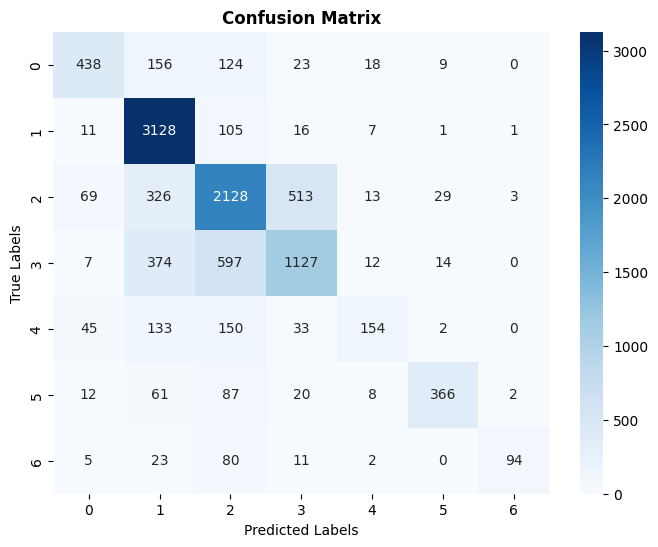

In [21]:
count_vec_boost(model=XGBClassifier,n_estimators=200,ngram_range=(1,2),learning_rate=0.07,max_features=10000)

In [22]:
# Training ML model using XGBoost Classifier and CountVectorizer
c_vect=CountVectorizer(max_df=0.7,max_features=1000,ngram_range=(1,2))
X_train_vect=c_vect.fit_transform(X_train)
X_test_vect=c_vect.transform(X_test)

In [23]:
model=XGBClassifier(n_estimators=200,learning_rate=0.07)
model.fit(X_train_vect,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.07, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [24]:
pred=model.predict(X_test_vect)
print(f'Accuracy :{accuracy_score(y_test,pred)}')

Accuracy :0.7168074404479453


In [25]:
# Prediction
def predict_sentiment(text,c_vect,model):

  """ It will predict the sentiment using trained Xgboost model"""
      # Define the mapping of indices to category labels
  label_mapping = {
        0: 'Anxiety',
        1: 'Normal',
        2: 'Depression',
        3: 'Suicidal',
        4: 'Stress',
        5: 'Bipolar',
        6: 'Personality disorder'
    }
  #transforming text into vector
  text_vec=c_vect.transform([text])

  #predicting
  predicted=model.predict(text_vec)[0]

  #mapping
  predicted_label=label_mapping[predicted]

  return {predicted_label : predicted }


In [26]:
text=X_train[2599]
text

'ya kahar freequds'

In [27]:
X_train[2599]

'ya kahar freequds'

In [28]:
y_train[2599]

np.int64(1)

In [29]:
predict_sentiment(text,c_vect,model)

{'Normal': np.int64(1)}

* Using CATBOOST Classifier

Accuracy using <class 'catboost.core.CatBoostClassifier'>: 0.6791306823574073
              precision    recall  f1-score   support

           0       0.75      0.50      0.60       768
           1       0.71      0.96      0.82      3269
           2       0.61      0.69      0.65      3081
           3       0.64      0.48      0.55      2131
           4       0.77      0.22      0.34       517
           5       0.90      0.54      0.68       556
           6       1.00      0.35      0.52       215

    accuracy                           0.68     10537
   macro avg       0.77      0.53      0.59     10537
weighted avg       0.69      0.68      0.66     10537



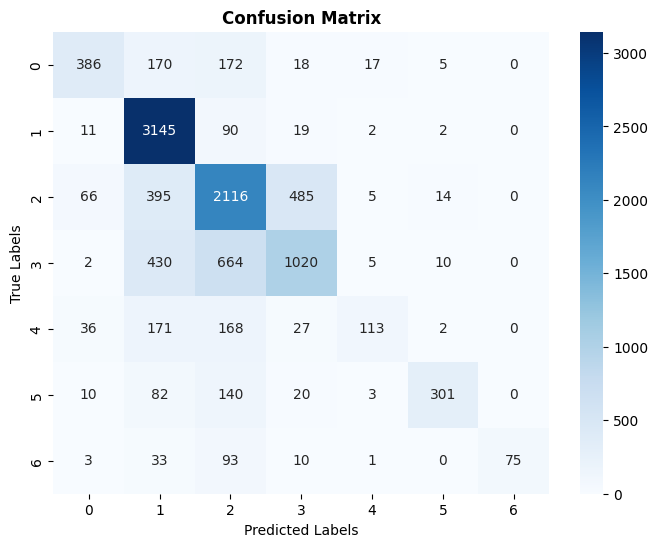

In [30]:
count_vec_boost(model=CatBoostClassifier,n_estimators=200,ngram_range=(1,2),learning_rate=0.07,max_features=10000)

- We get accuracy with Count Vectorizer using XGBoost as `70.5 %` and with CatBoost Classifier as `67.9 %`

# Tf-Idf Vectorizer

In [31]:
def tfidf_vec_boost(model,max_features, ngram_range, n_estimators,min_df=5,max_df=0.7, max_depth=3, learning_rate=0.07):

    vectorizer = TfidfVectorizer(max_df=max_df, max_features=max_features, ngram_range=ngram_range,sublinear_tf=True)
    X_train_vector = vectorizer.fit_transform(X_train)
    classifier = model(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,verbose=False)
    classifier.fit(X_train_vector, y_train)
    X_test_vector = vectorizer.transform(X_test)
    y_pred = classifier.predict(X_test_vector)
    print(f'Accuracy using {model}: {accuracy_score(y_test,y_pred)}')
    print(classification_report(y_test, y_pred))

    #Plotting classification report
    cm = confusion_matrix(y_test, y_pred)
    class_labels = y.unique().tolist()
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Reds', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix',fontweight='bold')
    plt.show()

* Using XGBoost with Tf-idf Vectorizer

Accuracy using <class 'xgboost.sklearn.XGBClassifier'>: 0.722122046123185
              precision    recall  f1-score   support

           0       0.77      0.66      0.71       768
           1       0.81      0.94      0.87      3269
           2       0.64      0.70      0.67      3081
           3       0.64      0.57      0.60      2131
           4       0.75      0.35      0.48       517
           5       0.86      0.69      0.76       556
           6       0.93      0.39      0.55       215

    accuracy                           0.72     10537
   macro avg       0.77      0.61      0.66     10537
weighted avg       0.72      0.72      0.71     10537



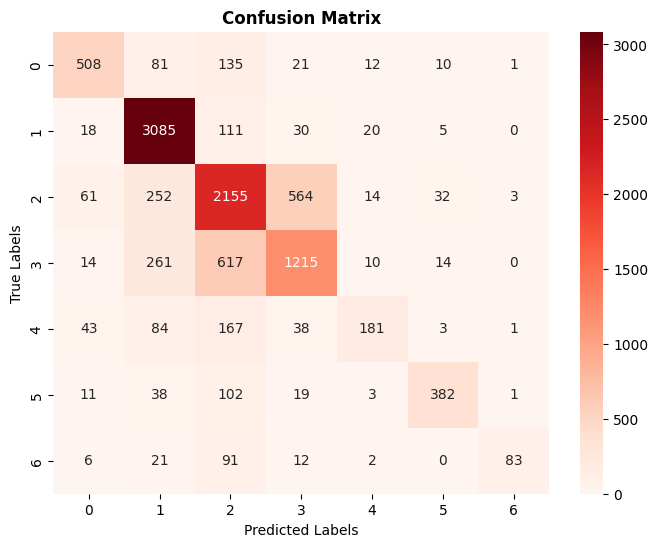

In [ ]:
tfidf_vec_boost(model=XGBClassifier,n_estimators=200,ngram_range=(1,3),learning_rate=0.07,max_features=2000,max_df=0.7,max_depth=5)

* Using CatBoost with Tf-idf Vectorizer

Accuracy using <class 'catboost.core.CatBoostClassifier'>: 0.6945999810192655
              precision    recall  f1-score   support

           0       0.75      0.57      0.65       768
           1       0.76      0.96      0.84      3269
           2       0.61      0.70      0.65      3081
           3       0.64      0.51      0.57      2131
           4       0.77      0.26      0.39       517
           5       0.90      0.56      0.69       556
           6       1.00      0.33      0.50       215

    accuracy                           0.69     10537
   macro avg       0.77      0.55      0.61     10537
weighted avg       0.70      0.69      0.68     10537



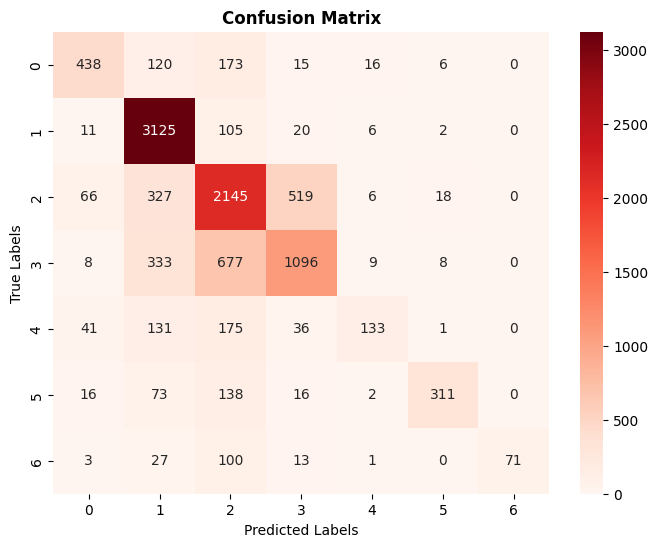

In [ ]:
tfidf_vec_boost(model=CatBoostClassifier,n_estimators=200,ngram_range=(1,3),learning_rate=0.07,max_features=2000,max_df=0.7,max_depth=5)

## Using Bidirectional and LSTM

In [ ]:
max_len=200
vocab_size=30000

# Tokenizing
tokenizer=Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)
tokenizer.fit_on_texts(X_test)

# for training data
seqs_train=tokenizer.texts_to_sequences(X_train)
X_pad_train=sequence.pad_sequences(seqs_train,maxlen=max_len)

# for testing data
seqs_test=tokenizer.texts_to_sequences(X_test)
X_pad_test=sequence.pad_sequences(seqs_test,maxlen=max_len)

In [ ]:
X=df['processed_statement'] #text column
y=df['status']      #label column

max_len = 150
vocab_size = 35000

# Tokenizing
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

# Sequence then pad_sequences
seqs = tokenizer.texts_to_sequences(X)
X_pad = sequence.pad_sequences(seqs, maxlen=max_len)

#Splitting the data into train:test into 80:20 ratio
X_train,X_test,y_train,y_test=train_test_split(X_pad,y,test_size=0.2,random_state=42,stratify=y)
print(f'X_train size:{X_train.shape}')
print(f'X_test size:{X_test.shape}')
y_train.shape

X_train size:(42144, 150)
X_test size:(10537, 150)


(42144,)

In [ ]:
# Creating model using keras' Sequential model with Embedding layers, Bidirectional, LSTM, Dense and dropout to avoid overfitting
model = Sequential()
model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=vocab_size,output_dim=256))
model.add(Bidirectional(LSTM(256, dropout=0.3,return_sequences=True)))
model.add(Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3)))
model.add(Dropout(0.3))
model.add(Dense(7,activation='softmax'))

#Compiling model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

#Final summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 256)       │     8,960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 512)       │     1,050,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,668,807 (40.70 MB)

 Trainable params: 10,668,807 (40.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_train.values

array([1, 2, 2, ..., 1, 5, 2])

In [ ]:
import numpy as np

In [ ]:
import tensorflow as tf

y_train_cat = tf.keras.utils.to_categorical(y_train)
y_test_cat = tf.keras.utils.to_categorical(y_test)

In [ ]:
y_train_cat

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [ ]:
# Using callbacks to monitor validation loss
callbacks=[
    EarlyStopping(monitor='val_loss',patience=3),
    ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3)
]

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data = (X_test, y_test),callbacks=callbacks)

Epoch 1/10
659/659 ━━━━━━━━━━━━━━━━━━━━ 647s 964ms/step - accuracy: 0.6406 - loss: 0.9537 - val_accuracy: 0.6856 - val_loss: 0.8083 - learning_rate: 0.0010
Epoch 2/10
659/659 ━━━━━━━━━━━━━━━━━━━━ 621s 943ms/step - accuracy: 0.7578 - loss: 0.6668 - val_accuracy: 0.7348 - val_loss: 0.7011 - learning_rate: 0.0010
Epoch 3/10
659/659 ━━━━━━━━━━━━━━━━━━━━ 621s 943ms/step - accuracy: 0.8136 - loss: 0.5191 - val_accuracy: 0.7434 - val_loss: 0.7024 - learning_rate: 0.0010
Epoch 4/10
659/659 ━━━━━━━━━━━━━━━━━━━━ 616s 935ms/step - accuracy: 0.8507 - loss: 0.4203 - val_accuracy: 0.7419 - val_loss: 0.7305 - learning_rate: 0.0010
Epoch 5/10
659/659 ━━━━━━━━━━━━━━━━━━━━ 610s 926ms/step - accuracy: 0.8793 - loss: 0.3421 - val_accuracy: 0.7403 - val_loss: 0.7983 - learning_rate: 0.0010


In [ ]:
#63.16,69.48  74.7,73.5  79.9

In [ ]:
y_pred=model.predict(X_test)
y_pred_prob=np.argmax(y_pred,axis=1)
print(classification_report(y_test,y_pred_prob))